In [9]:
import numpy as np  # Importe NumPy pour manipuler les tableaux et faire les calculs numériques.
import matplotlib.pyplot as plt  # Importe matplotlib pour afficher les graph.

Itération 0 : perte = 0.6931
Itération 200 : perte = 0.4349
Itération 400 : perte = 0.4007
Itération 600 : perte = 0.3904
Itération 800 : perte = 0.3864


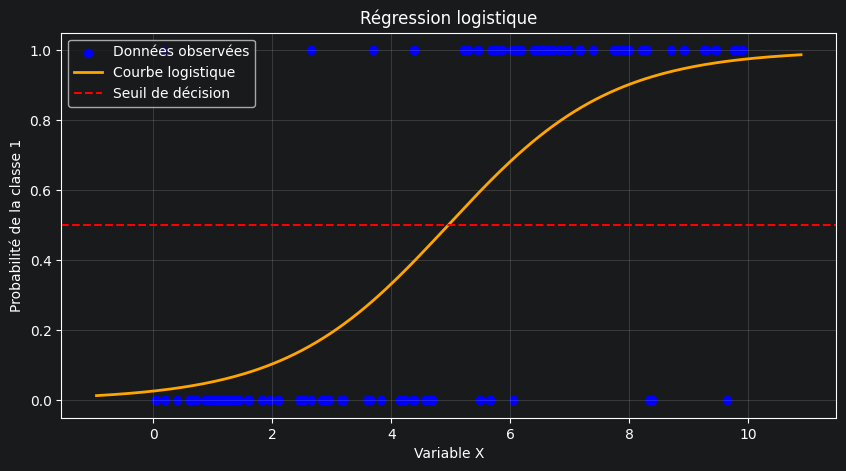

In [10]:
np.random.seed(0)  # Fixe la graine aléatoire pour obtenir les mêmes résultats à chaque exécution.
X = 10 * np.random.rand(100, 1)  # Génère 100 valeurs aléatoires comprises entre 0 et 10.
y = (X[:, 0] > 5).astype(int)  # Attribue la classe 1 si la valeur est supérieure à 5 et 0 sinon.

noise_idx = np.random.choice(100, 10, replace=False)  # Sélectionne 10 indices aléatoires pour ajouter du bruit aux classes.
y[noise_idx] = 1 - y[noise_idx]  # Inverse les classes sur les indices sélectionnés pour rendre les données moins parfaites.

def sigmoid(z):  # Définit la fonction sigmoïde qui transforme une valeur réelle en probabilité entre 0 et 1.
    return 1 / (1 + np.exp(-z))  # Retourne la valeur de la fonction sigmoïde appliquée à z.

def compute_loss(y_true, y_pred):  # Définit la fonction de coût log loss pour mesurer l'erreur de classification.
    epsilon = 1e-15  # Définit une petite valeur pour éviter de calculer log(0).
    return -np.mean(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))  # Calcule et retourne la perte moyenne.

def logistic_regression_scratch(X, y, learning_rate, iterations):  # Définit la fonction qui entraîne une régression logistique from scratch.
    m = X.shape[0]  # Récupère le nombre d'exemples dans le jeu de données.
    X_bias = np.hstack((np.ones((m, 1)), X))  # Ajoute une colonne de 1 à X pour représenter le biais.
    theta = np.zeros(X_bias.shape[1])  # Initialise les paramètres du modèle à zéro.
    losses = []  # Crée une liste vide pour stocker l'évolution de la perte.

    for i in range(iterations):  # Lance la boucle d'entraînement pendant le nombre d'itérations demandé.
        z = np.dot(X_bias, theta)  # Calcule la combinaison linéaire entre les données et les paramètres.
        y_pred = sigmoid(z)  # Transforme les scores linéaires en probabilités avec la sigmoïde.
        gradient = np.dot(X_bias.T, (y_pred - y)) / m  # Calcule le gradient moyen de la fonction de coût.
        theta = theta - learning_rate * gradient  # Met à jour les paramètres en suivant la descente de gradient.
        loss = compute_loss(y, y_pred)  # Calcule la perte actuelle du modèle.
        losses.append(loss)  # Ajoute la perte actuelle à la liste des pertes.

        if i % 200 == 0:  # Vérifie si l'itération actuelle est un multiple de 200.
            print(f"Itération {i} : perte = {loss:.4f}")  # Affiche la perte actuelle pour suivre l'apprentissage.

    return theta, losses  # Retourne les paramètres appris et l'historique des pertes.

theta, losses = logistic_regression_scratch(X, y, learning_rate=0.1, iterations=1000)  # Entraîne le modèle sur les données générées.

X_test = np.linspace(X.min() - 1, X.max() + 1, 200).reshape(-1, 1)  # Génère des points réguliers pour tracer une courbe lisse.
X_test_bias = np.hstack((np.ones((X_test.shape[0], 1)), X_test))  # Ajoute une colonne de biais aux données de test.
y_prob = sigmoid(np.dot(X_test_bias, theta))  # Calcule la probabilité prédite pour chaque point de test.

plt.figure(figsize=(10, 5))  # Crée une figure de taille 10 par 5.
plt.scatter(X, y, color='blue', label='Données observées')  # Affiche les données réelles sous forme de points bleus.
plt.plot(X_test, y_prob, color='orange', linewidth=2, label='Courbe logistique')  # Trace la courbe logistique prédite.
plt.axhline(y=0.5, color='red', linestyle='--', label='Seuil de décision')  # Trace le seuil de décision horizontal à 0.5.
plt.title('Régression logistique')  # Ajoute un titre au graph.
plt.xlabel('Variable X')  # Ajoute un label à l'axe des abscisses.
plt.ylabel('Probabilité de la classe 1')  # Ajoute un label à l'axe des ordonnées.
plt.legend()  # Affiche la légende du graph.
plt.grid(True, alpha=0.3)  # Ajoute une grille légère au graph.
plt.show()  # Affiche le graph principal.